# Pre-processing

Set PATH for package imports

In [1]:
import os
import sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root added to sys.path


Processing `npt-HK4.gro` file into pandas dataframe

In [2]:
from utils import gro_processing as gp

# Data directory can be accessed due to root PATH we set previously
path = 'data/npt-HK4.gro'
abs_path = os.path.join(project_root, path)

# Extracts data from .gro file into multi-index DataFrame (unsorted)
df_gro, title, num_atoms, box_dimensions = gp.read_gro(abs_path, multiply=10, positions=True, velocities=False) # convert nm to Å  
    
# Checking
# df_gro

# Generating Molecule Meshes

Create `mol_meshes` dictionary, which contains 1501 individual molecule mesh. (i.e. `{1: mesh1, 2: mesh2, ... 1501: mesh1501}`)

In [5]:
from utils.generate_mol_meshes import molecules_to_meshes

mol_meshes = molecules_to_meshes(df_gro, box_dimensions, 
                                 sphere_radius_scale=0.8, 
                                 sphere_subdiv=2, 
                                 bond_radius=0.1,
                                 num_processes=None, 
                                 context='spawn')
print(len(mol_meshes))        # 1501
print(mol_meshes[1])          # trimesh.Trimesh object

Processing 1501 molecules with 8 logical cores: 100%|██████████| 1501/1501 [01:13<00:00, 20.44it/s]


1501
<trimesh.Trimesh(vertices.shape=(18308, 3), faces.shape=(35904, 3))>


## Export meshes

Users have two options to export meshes as `.npz` or `.ply` file.
- `.npz` is much smaller $\sim400\,\mathrm{MB}$, but exports longer $\sim50\,\mathrm{s}$
- `.ply` file is larger $\sim1.00\,\mathrm{GB}$, but exports shorter $\sim20\,\mathrm{s}$

In [6]:
from utils.generate_mol_meshes import export_meshes

# Export to either npz file or ply directory
# export_meshes(mol_meshes, path=path, export_format='npz', num_processes=None, context='fork')
export_meshes(mol_meshes, path=path, export_format='ply', num_processes=None, context='fork')

ValueError: cannot find context for 'fork'

# Import meshes

Users have two options to import meshes from `.npz` or `.ply` file.
- `.npz` longer import $\sim20\,\mathrm{s}$ (parallel does not work well here) 
- `.ply` shorter import $\sim8\,\mathrm{s}$

In [ ]:
from utils.generate_mol_meshes import import_meshes

# Import either npz files or ply directory (auto-detect)
# mol_meshes = import_meshes(path='npt-HK4_meshes.npz', num_processes=None, context='fork')
mol_meshes = import_meshes(path='npt-HK4_meshes', num_processes=None, context='fork')

ValueError: Unsupported path or file type: npt-HK4_meshes

# Generate neighbors pairs (Blocking Algo)

All the functions have been merged into main function `find_neighbors`. User can export to CSV, data that are exported include:
- centroids
- e-centroids
- neighbor_candidates
- neighbor_pairs

This function is designed to accommodate incomplete `mol_meshes` data. For example, if the following meshes are missing: `mol_id=[1,2,4]`, the output will simply exclude them (e.g., `{3:trimesh,5:trimesh,…,1501:trimesh}`). Consequently, the blocking algorithm continues uninterrupted using only the available meshes.

In [7]:
from utils.blocking_algo import find_neighbor_pairs

neighbor_pairs, e_centroids, centroids, neighbor_candidates = find_neighbor_pairs(mol_meshes, df_gro, box_dimensions, path, k=10, export_csv=True)

print(e_centroids)
print(centroids)
print("Neighbor candidates:",len(neighbor_candidates))
print("Neighbor pairs:", len(neighbor_pairs))

Insert atom id for one molecule.
Use the following format: '20-30; 30; 20; 40-60' (for range use '-', for multi-input split using ';' 
----------------------------------------
You entered: [32-53]
----------------------------------------
Selected atom_id(s): [32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53]


Testing neighbor pairs: 100%|██████████| 2206/2206 [03:29<00:00, 10.52it/s]


----------------------------------------
Successfully exported npt-HK4_e_centroids.csv
Successfully exported npt-HK4_centroids.csv
Successfully exported npt-HK4_neighbor_candidates.csv
Exported npt-HK4_neighbor_pairs.csv
{1: array([ 15.75727273,   3.93227273, 111.68174545]), 2: array([  4.935     ,   7.26454545, 108.39227273]), 3: array([  7.66909091, 108.07818182,   8.69727273]), 4: array([ 1.52731818, 10.37727273,  1.91959091]), 5: array([55.41954545,  1.17957273, 58.02727273]), 6: array([92.80727273, 66.47681818,  7.53409091]), 7: array([ 68.19590909, 100.06045455,  71.07681818]), 8: array([25.97636364, 68.23909091, 69.13727273]), 9: array([79.10227273, 92.49590909, 84.83954545]), 10: array([17.76818182, 88.35590909, 23.54772727]), 11: array([78.41590909, 97.155     , 21.39      ]), 12: array([73.15636364, 62.76681818, 26.63363636]), 13: array([85.55136364, 65.40545455, 70.38954545]), 14: array([111.43042727,   1.28506364,  47.98727273]), 15: array([105.975     ,  38.25545455,   7.7

# Import neighbor pairs

Because finding `neighbor_pairs` is heavy.

In [8]:
from utils.blocking_algo import import_csv

e_centroids = import_csv('./npt-HK4_e_centroids.csv')
centroids = import_csv('./npt-HK4_centroids.csv')
neighbor_candidates = import_csv('./npt-HK4_neighbor_candidates.csv')
neighbor_pairs = import_csv('./npt-HK4_neighbor_pairs.csv')
fail_1 = import_csv('./npt-HK4_fail_1.csv')  # Should raise error

# print('-' * 40)
# print(f'{e_centroids=}')
# print(f'{centroids=}')
# print(f'{neighbor_pairs=}')
# print(f'{neighbor_candidates=}')

Successfully imported centroids CSV file: './npt-HK4_e_centroids.csv'.
Successfully imported centroids CSV file: './npt-HK4_centroids.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_candidates.csv'.
Successfully imported neighbors CSV file: './npt-HK4_neighbor_pairs.csv'.
[Errno 2] No such file or directory: './npt-HK4_fail_1.csv'


# Verify blocking molecules

Immediately creates a pyglet window for users to visually verify blocking.

In [9]:
from utils.blocking_algo import view_molecule

# 107, 491, 530
mol_id = 530 # molecule ID to visualize
view_molecule(mol_id, e_centroids, mol_meshes, neighbor_candidates, neighbor_pairs, 
              view_unpaired_mols=True, distinct_color=True, alpha_value=100)

Neighbor pairs for molecule 530: [802, 852]
Non-paired neighbors are: [150]
----------------------------------------
You have selected: [150]
----------------------------------------
You are now viewing molecules [150, 530, 802, 852]


ModuleNotFoundError: No module named 'pyglet'

Generate 3D graph network and histogram of number of pairs per molecule

MovieWriter ffmpeg unavailable; using Pillow instead.


The pairs without e_coupling has been exported to: npt-HK4_pairs_without_e_coupling.txt


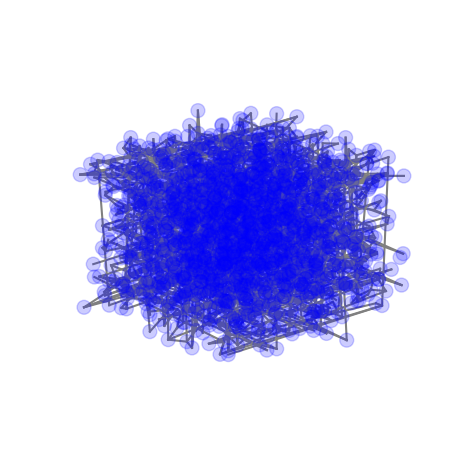

Average pairs per molecule: 2.732844770153231


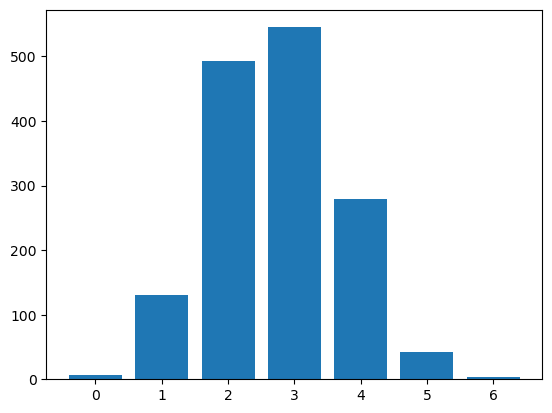

In [11]:
from utils import networkx_graph_making as ngm

# User must input centroids csv, neighbor pairs csv and e_coupling data txt file, sample of format of txt file can be found under data/e-coupling_with_nn_distance.txt
G = ngm.networkx_graph_making(centroids_path = "npt-HK4_centroids.csv",
                          neighbor_pairs_path = "npt-HK4_neighbor_pairs.csv",
                          e_coupling_data_path = "../../data/e-coupling_with_nn_distance.txt",
                          pairs_without_e_coupling_to_txt = True,  # Set to True to export to txt file
                          plot_3D_to_gif = True                     # Set to True to produce gif of graph
                          )

ngm.average_pairs_per_molecule(G) # Input graph object generated from the above object to get average pairs per molecule